In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import numpy as np
from collections import Counter
from nltk.tokenize import MWETokenizer
from scipy.stats import chi2
import re
import ast

# Applying filter for the scrabed files

In [2]:
stop_words = set(stopwords.words("english"))

extra_stop_words = {
    "http", "https", "www", "external", "links", "link", "homepage",
    "website", "official", "site", "retrieved", "archive", "archived",
    "accessed", "html", "htm", "asp", "index", "php", "url"
}

stop_words = stop_words.union(extra_stop_words)

def alpha_cleaner(tokens):
    text = " ".join(tokens).lower()

    # Remove complete External links / References sections early
    text = re.sub(
        r"==\s*(external\s+links?|references|see\s+also|notes)\s*==.*",
        " ",
        text,
        flags=re.DOTALL | re.IGNORECASE
    )

    # Remove URLs BEFORE removing punctuation
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"www\.\S+", " ", text)

    # Remove broken/flattened URLs that may already be tokenized
    text = re.sub(r"\bwww[a-z0-9]+(?:com|org|net|gov|edu)\b", " ", text)
    text = re.sub(r"\b[a-z0-9]+(?:airport|airports)?(?:com|org|net|gov|edu)\b", " ", text)

    # Remove file/image links
    text = re.sub(r"\[\[(?:file|image):[^\]]+\]\]", " ", text, flags=re.IGNORECASE)

    # Remove wiki links but keep visible text
    text = re.sub(r"\[\[(?:[^|\]]*\|)?([^\]]+)\]\]", r"\1", text)

    # Remove templates
    for _ in range(5):
        text = re.sub(r"\{\{[^{}]*\}\}", " ", text)

    # Remove tables and HTML tags
    text = re.sub(r"\{\|.*?\|\}", " ", text, flags=re.DOTALL)
    text = re.sub(r"<[^>]+>", " ", text)

    # Keep important special terms
    text = re.sub(r"\b(9/11|9-11|911|september\s+11)\b", "september_eleven", text)
    text = re.sub(r"\b2001\b", "year_two_thousand_one", text)

    # Remove everything except letters, underscores and spaces
    text = re.sub(r"[^a-z_ ]", " ", text)

    tokens = text.split()

    clean_tokens = [
        w for w in tokens
        if (w.isalpha() or "_" in w)
        and w not in stop_words
        and len(w) > 3
        and not w.startswith("www")
        and not w.endswith(("com", "org", "net", "gov", "edu", "html", "htm"))
    ]

    return clean_tokens

In [4]:
years = range(2003,2026)
records = []

for year in years:
    path = (f"AIRPORT_RAW_{year}.json")
    
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    for airport in data:
        clean_tokens = alpha_cleaner(airport["Tokens"])
        records.append({
            'Year': airport['Year'],
            'token_text': clean_tokens
        })

df_tokens = pd.DataFrame(records)
df_tokens.to_csv('airport_tokens_v2.csv', index=False)

In [7]:
print(df_tokens.columns.tolist())

['Year', 'token_text']


In [8]:
print(df_tokens.head())
print(df_tokens["token_text"].iloc[3][:-1])

   Year                                         token_text
0  2003  [birmingham, international, airport, airport, ...
1  2003                                                 []
2  2003  [huntsville, international, airport, airport, ...
3  2003  [mobile, regional, airport, airport, mobile, a...
4  2003                                                 []
['mobile', 'regional', 'airport', 'airport', 'mobile', 'alabama', 'near', 'pasagoula', 'mississippi', 'uses', 'iata', 'airport', 'code', 'following', 'airlines', 'mobile', 'regional', 'airport', 'atlantic', 'southeast', 'airlines', 'delta', 'connection', 'continental', 'express', 'delta', 'lines', 'pinnacle', 'airlines', 'northwest', 'airlink']


# Lemmatizing the two tokens documents

In [10]:
# Only use this line if df_tokens was loaded from a CSV
#df_tokens["tokens"] = df_tokens["tokens"].apply(ast.literal_eval)

wnl = WordNetLemmatizer()

df_tokens["token_text"] = df_tokens["token_text"].apply(
    lambda token_list: [wnl.lemmatize(w) for w in token_list]
)

df_tokens.to_csv("airport_tokens_lemmatized.csv", index=False)

In [12]:
print(df_tokens.head())
print(df_tokens["token_text"].iloc[0][:30])

   Year                                         token_text
0  2003  [birmingham, international, airport, airport, ...
1  2003                                                 []
2  2003  [huntsville, international, airport, airport, ...
3  2003  [mobile, regional, airport, airport, mobile, a...
4  2003                                                 []
['birmingham', 'international', 'airport', 'airport', 'birmingham', 'alabama', 'airport', 'iata', 'airport', 'code', 'whereas', 'birmingham', 'international', 'airport', 'birmingham', 'international', 'airport', 'united', 'kingdom', 'code', 'following', 'airline', 'birmingham', 'international', 'airport', 'wisconsin', 'united', 'express', 'american', 'airline']


The lemmatized documents for the two peirods ensures that the inflected forms of the word are reduced to their base form. For example if a word such as "smallest" appears then it will appear "small" which is its base form.

# Creating the Bigrams for each year and making the CHI squre test

In [13]:
# Compute all n_grams:
def create_n_grams(tokenized_sentences, N):
    n_grams = []
    for sentence in tokenized_sentences:
        for i in range(len(sentence)-N +1):
            n_grams.append(tuple(sentence[i:i+N]))
    return n_grams

# bigrams_by_year = {}
# bigram_counts_by_year = {}

# # Ensuring that each airport for each year has one seperate sentences so it won't conflict with the other years
# for year, group in df_tokens.groupby('year'):
#     sentences = group['tokens'].tolist()
#     bigrams = create_n_grams(sentences, 2)
#     bigrams_by_year[year] = bigrams
#     bigram_counts_by_year[year] = Counter(bigrams)



Computing the CHI squre test:

In [14]:
# Computes the chi squre test for eall the bigrams 
def compute_chi_square_for_bigram(w1, w2, bigram_counts, first_word_counts, second_word_counts, N):
    n11 = bigram_counts[(w1, w2)]
    n1_ = first_word_counts[w1]
    n_1 = second_word_counts[w2]
    n10 = n1_ - n11
    n01 = n_1 - n11
    n00 = N - (n11 + n10 + n01)
    R1  = n11 + n10
    R2  = n01 + n00
    C1  = n11 + n01
    C2  = n10 + n00
    E11 = R1 * C1 / N
    E12 = R1 * C2 / N
    E21 = R2 * C1 / N
    E22 = R2 * C2 / N
    O   = [[n11, n10], [n01, n00]]
    E   = [[E11, E12], [E21, E22]]
    chi2_score = sum(
        (O[i][j] - E[i][j])**2 / E[i][j]
        for i in range(2) for j in range(2) if E[i][j] > 0
    )
    return chi2_score

# Computing the p-value:
def compute_p_value(chi2_score):
    return chi2.sf(chi2_score, df=1)

In [16]:
bigrams_by_year           = {}
bigram_counts_by_year     = {}
first_word_counts_by_year = {}
second_word_counts_by_year= {}
chi2_results_by_year      = {}

# These forloops makes sure that all the bigrams and the CHI test is independent for each year and airport

for year, group in df_tokens.groupby('Year'):
    # Ensureing the bigrams is independent for each year and airport
    sentences = group['token_text'].tolist()
    bigrams   = create_n_grams(sentences, 2)
    bigrams_by_year[year]       = bigrams
    bigram_counts_by_year[year] = Counter(bigrams)

    bigram_counts      = bigram_counts_by_year[year]
    first_word_counts  = Counter()
    second_word_counts = Counter()
    for (a, b), c in bigram_counts.items():
        first_word_counts[a]  += c
        second_word_counts[b] += c
    first_word_counts_by_year[year]  = first_word_counts
    second_word_counts_by_year[year] = second_word_counts

    # Now does the same
    N = sum(bigram_counts.values())
    if N == 0:
        continue

    results = []
    
    for (w1, w2), count in bigram_counts.items():
        score   = compute_chi_square_for_bigram(
            w1, w2, bigram_counts,
            first_word_counts, second_word_counts, N
        )
        p_value = compute_p_value(score)
        results.append({'w1': w1, 'w2': w2, 'count': count,
                        'chi2': score, 'p_value': p_value})

    chi2_results_by_year[year] = pd.DataFrame(results).sort_values(
        'chi2', ascending=False
    )

In [17]:
from tqdm import tqdm

collocations = []

for (w1, w2), freq in tqdm(bigram_counts.items(), desc="Computing collocations"):
    if freq > 50:
        chi2_score = compute_chi_square_for_bigram(w1, w2, bigram_counts, first_word_counts, second_word_counts, N)
        p_val = compute_p_value(chi2_score)

        if p_val < 0.001:
            collocations.append(((w1, w2), freq, chi2_score, p_val))

collocations = sorted(collocations, key=lambda x: x[1], reverse=True)

Computing collocations: 100%|██████████| 269642/269642 [00:00<00:00, 1018896.20it/s]


In [18]:
for bg, freq, chi2_score, p in collocations[:20]:
    print(bg, freq)

('international', 'airport') 22100
('access', 'date') 10259
('cite', 'title') 6061
('cite', 'news') 2879
('status', 'live') 2879
('long', 'position') 2404
('label_size', 'marksize') 2245
('date', 'december') 2193
('regional', 'airport') 2154
('marksize', 'location') 1939
('date', 'august') 1933
('date', 'march') 1877
('united', 'state') 1800
('date', 'november') 1787
('date', 'july') 1782
('date', 'october') 1763
('date', 'january') 1721
('date', 'june') 1710
('fort', 'worth') 1606
('date', 'february') 1535


In [20]:
# Collocation merging — scoped per year and per airport
for year, group in df_tokens.groupby('Year'):
    year_chi2           = chi2_results_by_year[year]
    collocation_bigrams = list(zip(year_chi2['w1'], year_chi2['w2']))

    if not collocation_bigrams:              # fixed syntax
        continue

    mwe_tokenizer = MWETokenizer(collocation_bigrams, separator='_')

    for idx, row in group.iterrows():
        if isinstance(row['token_text'], list):
            df_tokens.at[idx, 'token_text'] = mwe_tokenizer.tokenize(row['token_text'])


In [22]:
all_tokens = [
    token
    for token_list in df_tokens["token_text"]
    for token in token_list
]

Counter(all_tokens).most_common(20)

[('international_airport', 139371),
 ('cite_title', 23220),
 ('access_date', 22495),
 ('regional_airport', 13295),
 ('cite_news', 12477),
 ('united_state', 11725),
 ('fort_worth', 10379),
 ('long_position', 9812),
 ('aviation_administration', 9758),
 ('federal_aviation', 9750),
 ('dallas_fort', 9518),
 ('status_live', 9163),
 ('label_size_marksize', 9085),
 ('marksize_location', 8322),
 ('number_length', 8211),
 ('length_surface', 8183),
 ('stat_data', 8057),
 ('stat_header', 8026),
 ('american_airline', 7961),
 ('united_states_long', 7943)]

# TF-IDF wordcloud for the time period 2003-2011

In [25]:
stop_words = [
    # Core airport words
    "airport", "airports", "international", "regional", "municipal",
    "national", "public", "commercial", "aviation", "airfield",
    "terminal", "terminals", "concourse", "concourses", "gate",
    "runway", "runways", "aircraft", "passenger", "passengers",
    "flight", "flights", "destination", "destinations", "route",
    "service", "services", "served", "serves", "serving",
    "operation", "operations", "facility",

    # Airline/company words
    "airline", "airlines", "airway", "airways", "express",
    "connection", "eagle", "airlink", "operated", "operator",
    "carrier", "carriers", "seasonal", "nonstop",

    # Common US/location words that are boring in this project
    "city", "county", "state", "states", "united",
    "location", "located", "area", "near", "downtown",
    "north", "south", "east", "west",
    "northeast", "northwest", "southeast", "southwest",
    "fort", "lake", "worth",

    # Airport-code / infobox / metadata words
    "iata", "icao", "faa", "code", "codes",
    "infobox", "image", "label", "position",
    "coordinate", "coordinates", "coor",
    "type", "region", "frame", "title", "name",
    "status", "opened", "closest", "town",

    # Runway/table-specific words
    "length", "width", "surface", "asphalt", "concrete",
    "paved", "elevation", "mile", "miles", "km", "ft",
    "acre", "acres", "angle", "distance",

    # Wikipedia/reference words
    "cite", "access", "accessdate", "publisher", "news",
    "work", "date", "year", "data", "last", "first",
    "convert", "stat", "number",

    # Months, because they often come from citations/access dates
    "january", "february", "march", "april", "june", "july",
    "august", "october", "november", "december",

    # Common airline names that dominate but are not useful for security analysis
    "american", "delta", "united", "southwest", "northwest",
    "continental", "alaska", "boeing", "comair", "mesa",
    "pinnacle", "mesaba", "chautauqua", "skywest", "expressjet",

    # Very common city/location words from your airport documents
    "dallas", "fort", "worth",
    "washington", "chicago", "denver", "york", "atlanta",
    "angeles", "los", "orlando", "phoenix", "charlotte",
    "minneapolis", "houston", "paul", "beach", "seattle",
    "newark", "francisco", "san", "detroit", "portland",
    "texas", "philadelphia", "jackson", "miami", "louis",
    "salt", "lake", "vegas", "vega", "boston", "tacoma",
    "lauderdale", "mexico", "memphis", "cincinnati", "tampa",
    "diego", "baltimore", "pittsburgh", "kansas", "austin",
    "nashville", "cleveland", "anchorage", "oakland",
    "toronto", "orleans", "indianapolis", "saint",

]
# Loading the lemmatized tokens csv file:
df_tokens = pd.read_csv("airport_tokens_lemmatized.csv")

# Convert token lists to strings for TfidfVectorizer
df_tokens["token_text"] = df_tokens["token_text"].apply(
    lambda tokens: " ".join(tokens) if isinstance(tokens, list) else tokens
)

vectorizer = TfidfVectorizer(
    stop_words=list(STOPWORDS.union(stop_words)),
    ngram_range=(1, 1)
)

tfidf_matrix = vectorizer.fit_transform(df_tokens["token_text"])
feature_names = vectorizer.get_feature_names_out()


c:\Users\david\miniconda3\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


# TD-IDF WordCloud visualisations for the whole period 2003-2025

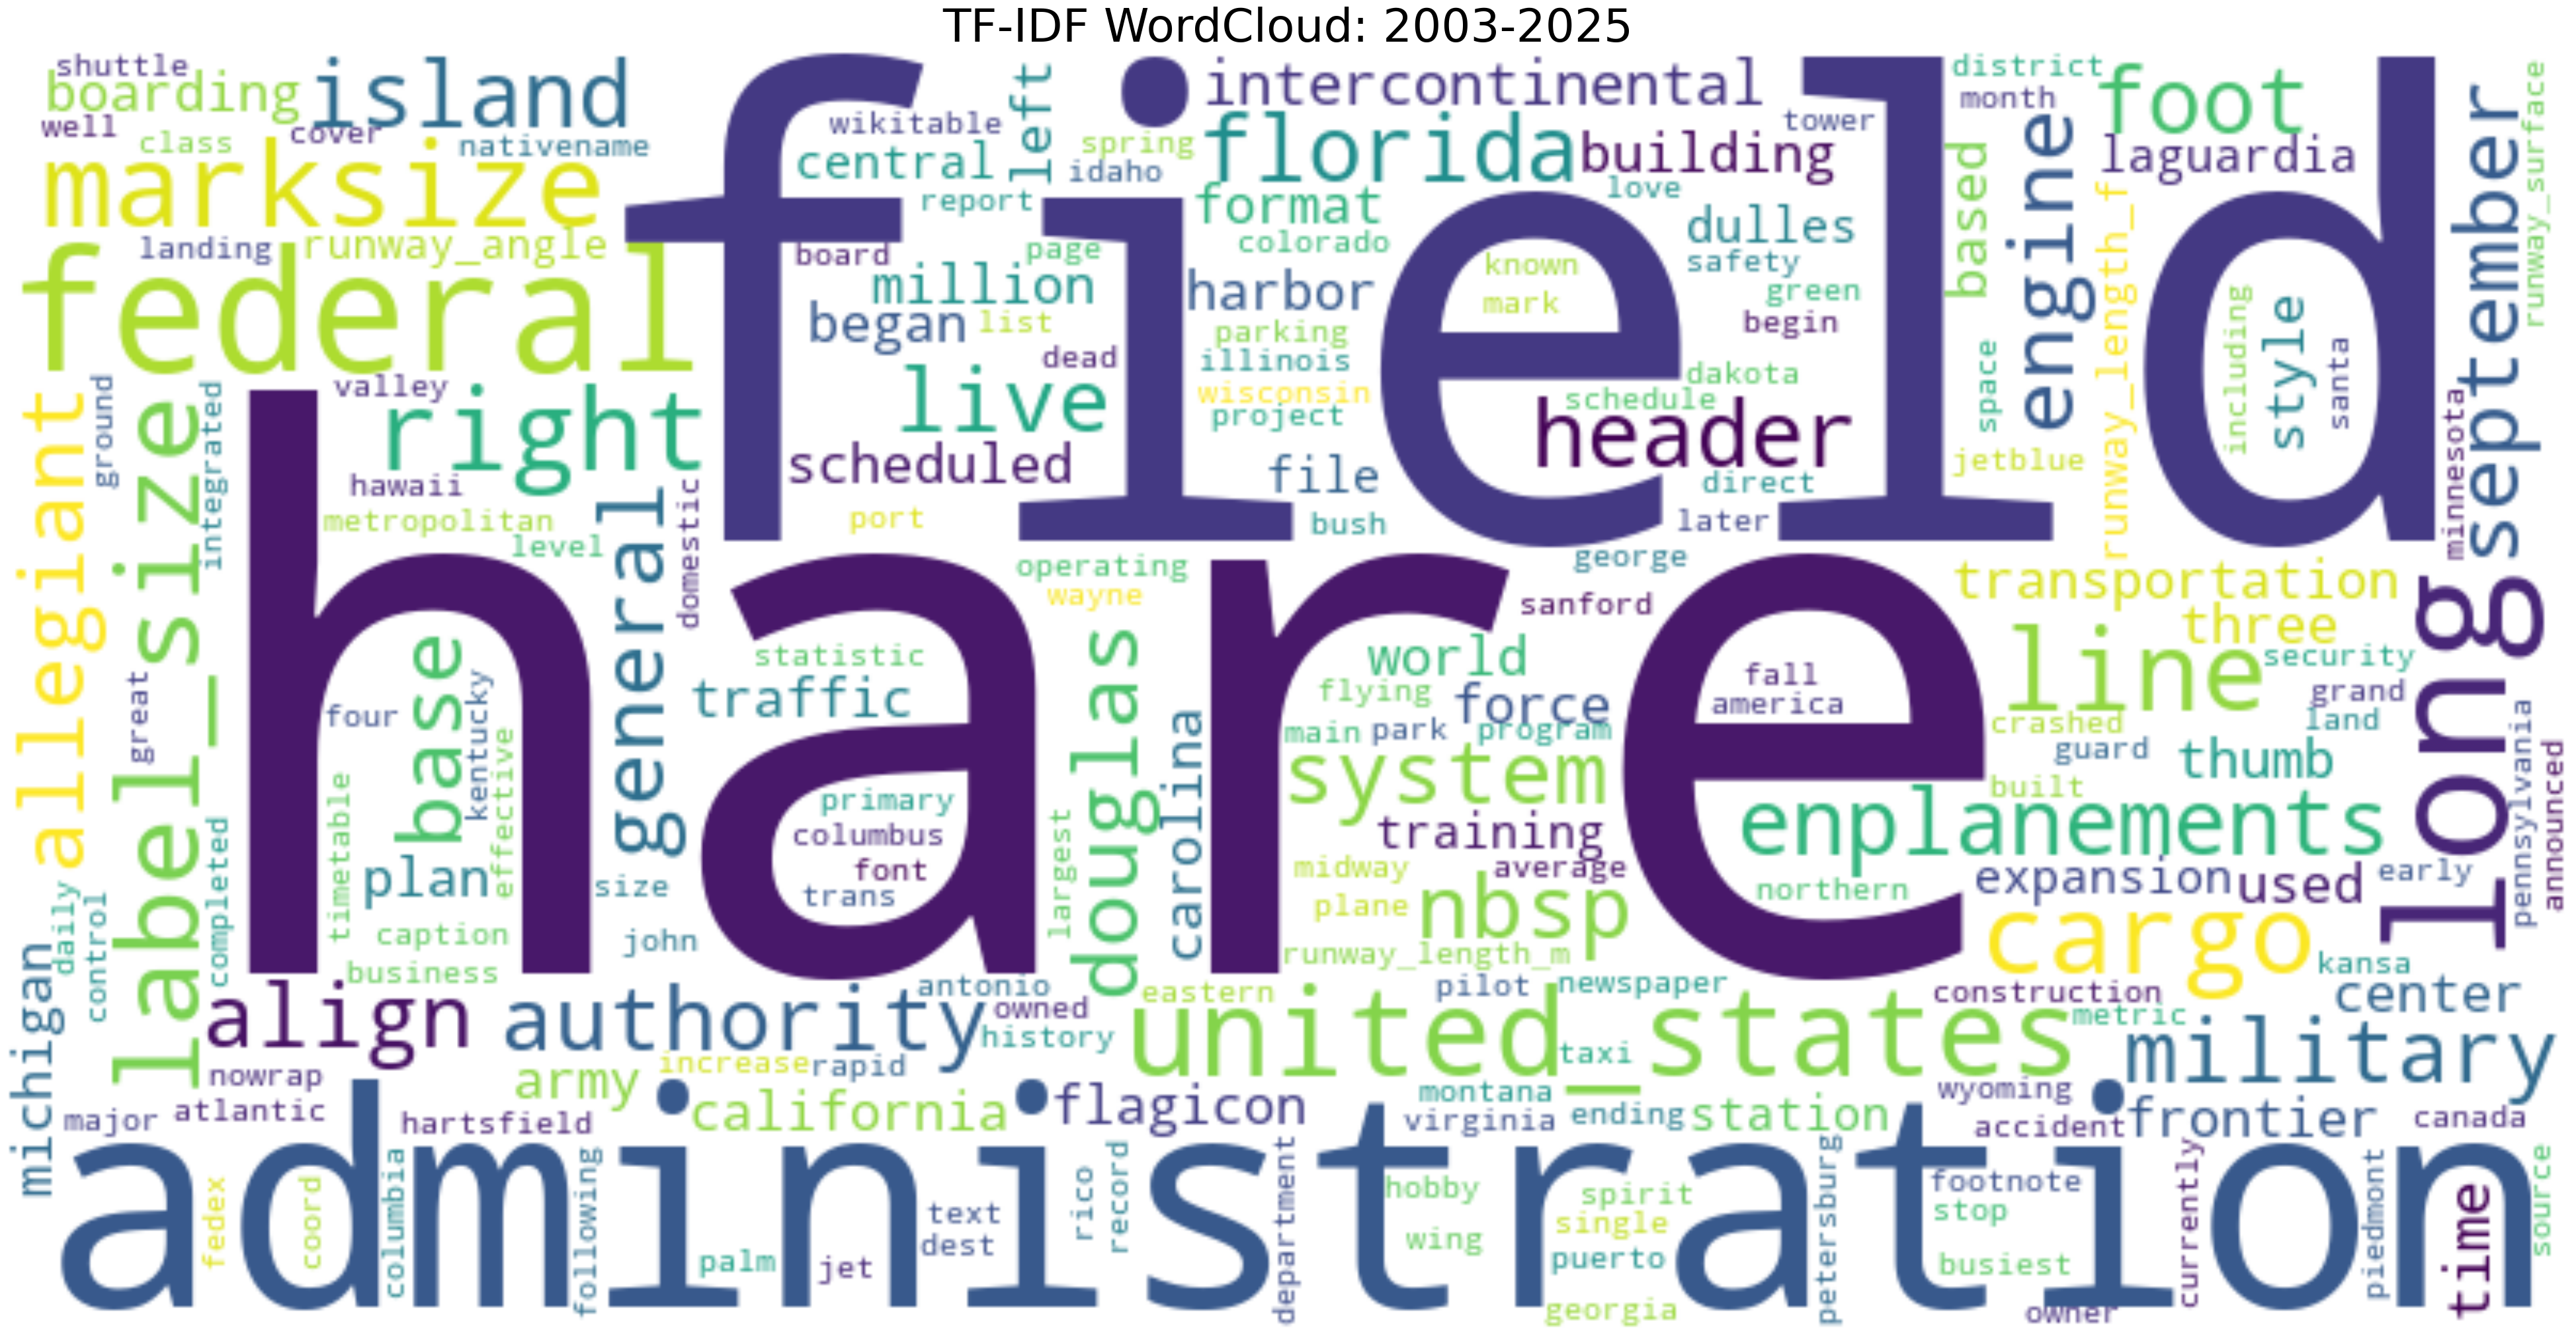

In [27]:
# Sum TF-IDF scores across all documents (stays sparse until the final small sum)
scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()  # shape: (18307,)

word_scores = dict(zip(feature_names, scores))

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
).generate_from_frequencies(word_scores)

plt.figure(figsize=(50, 65))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("TF-IDF WordCloud: 2003-2025", fontsize=50)
plt.show()

# TF-IDF WordCloud for every year visualized in a grid:

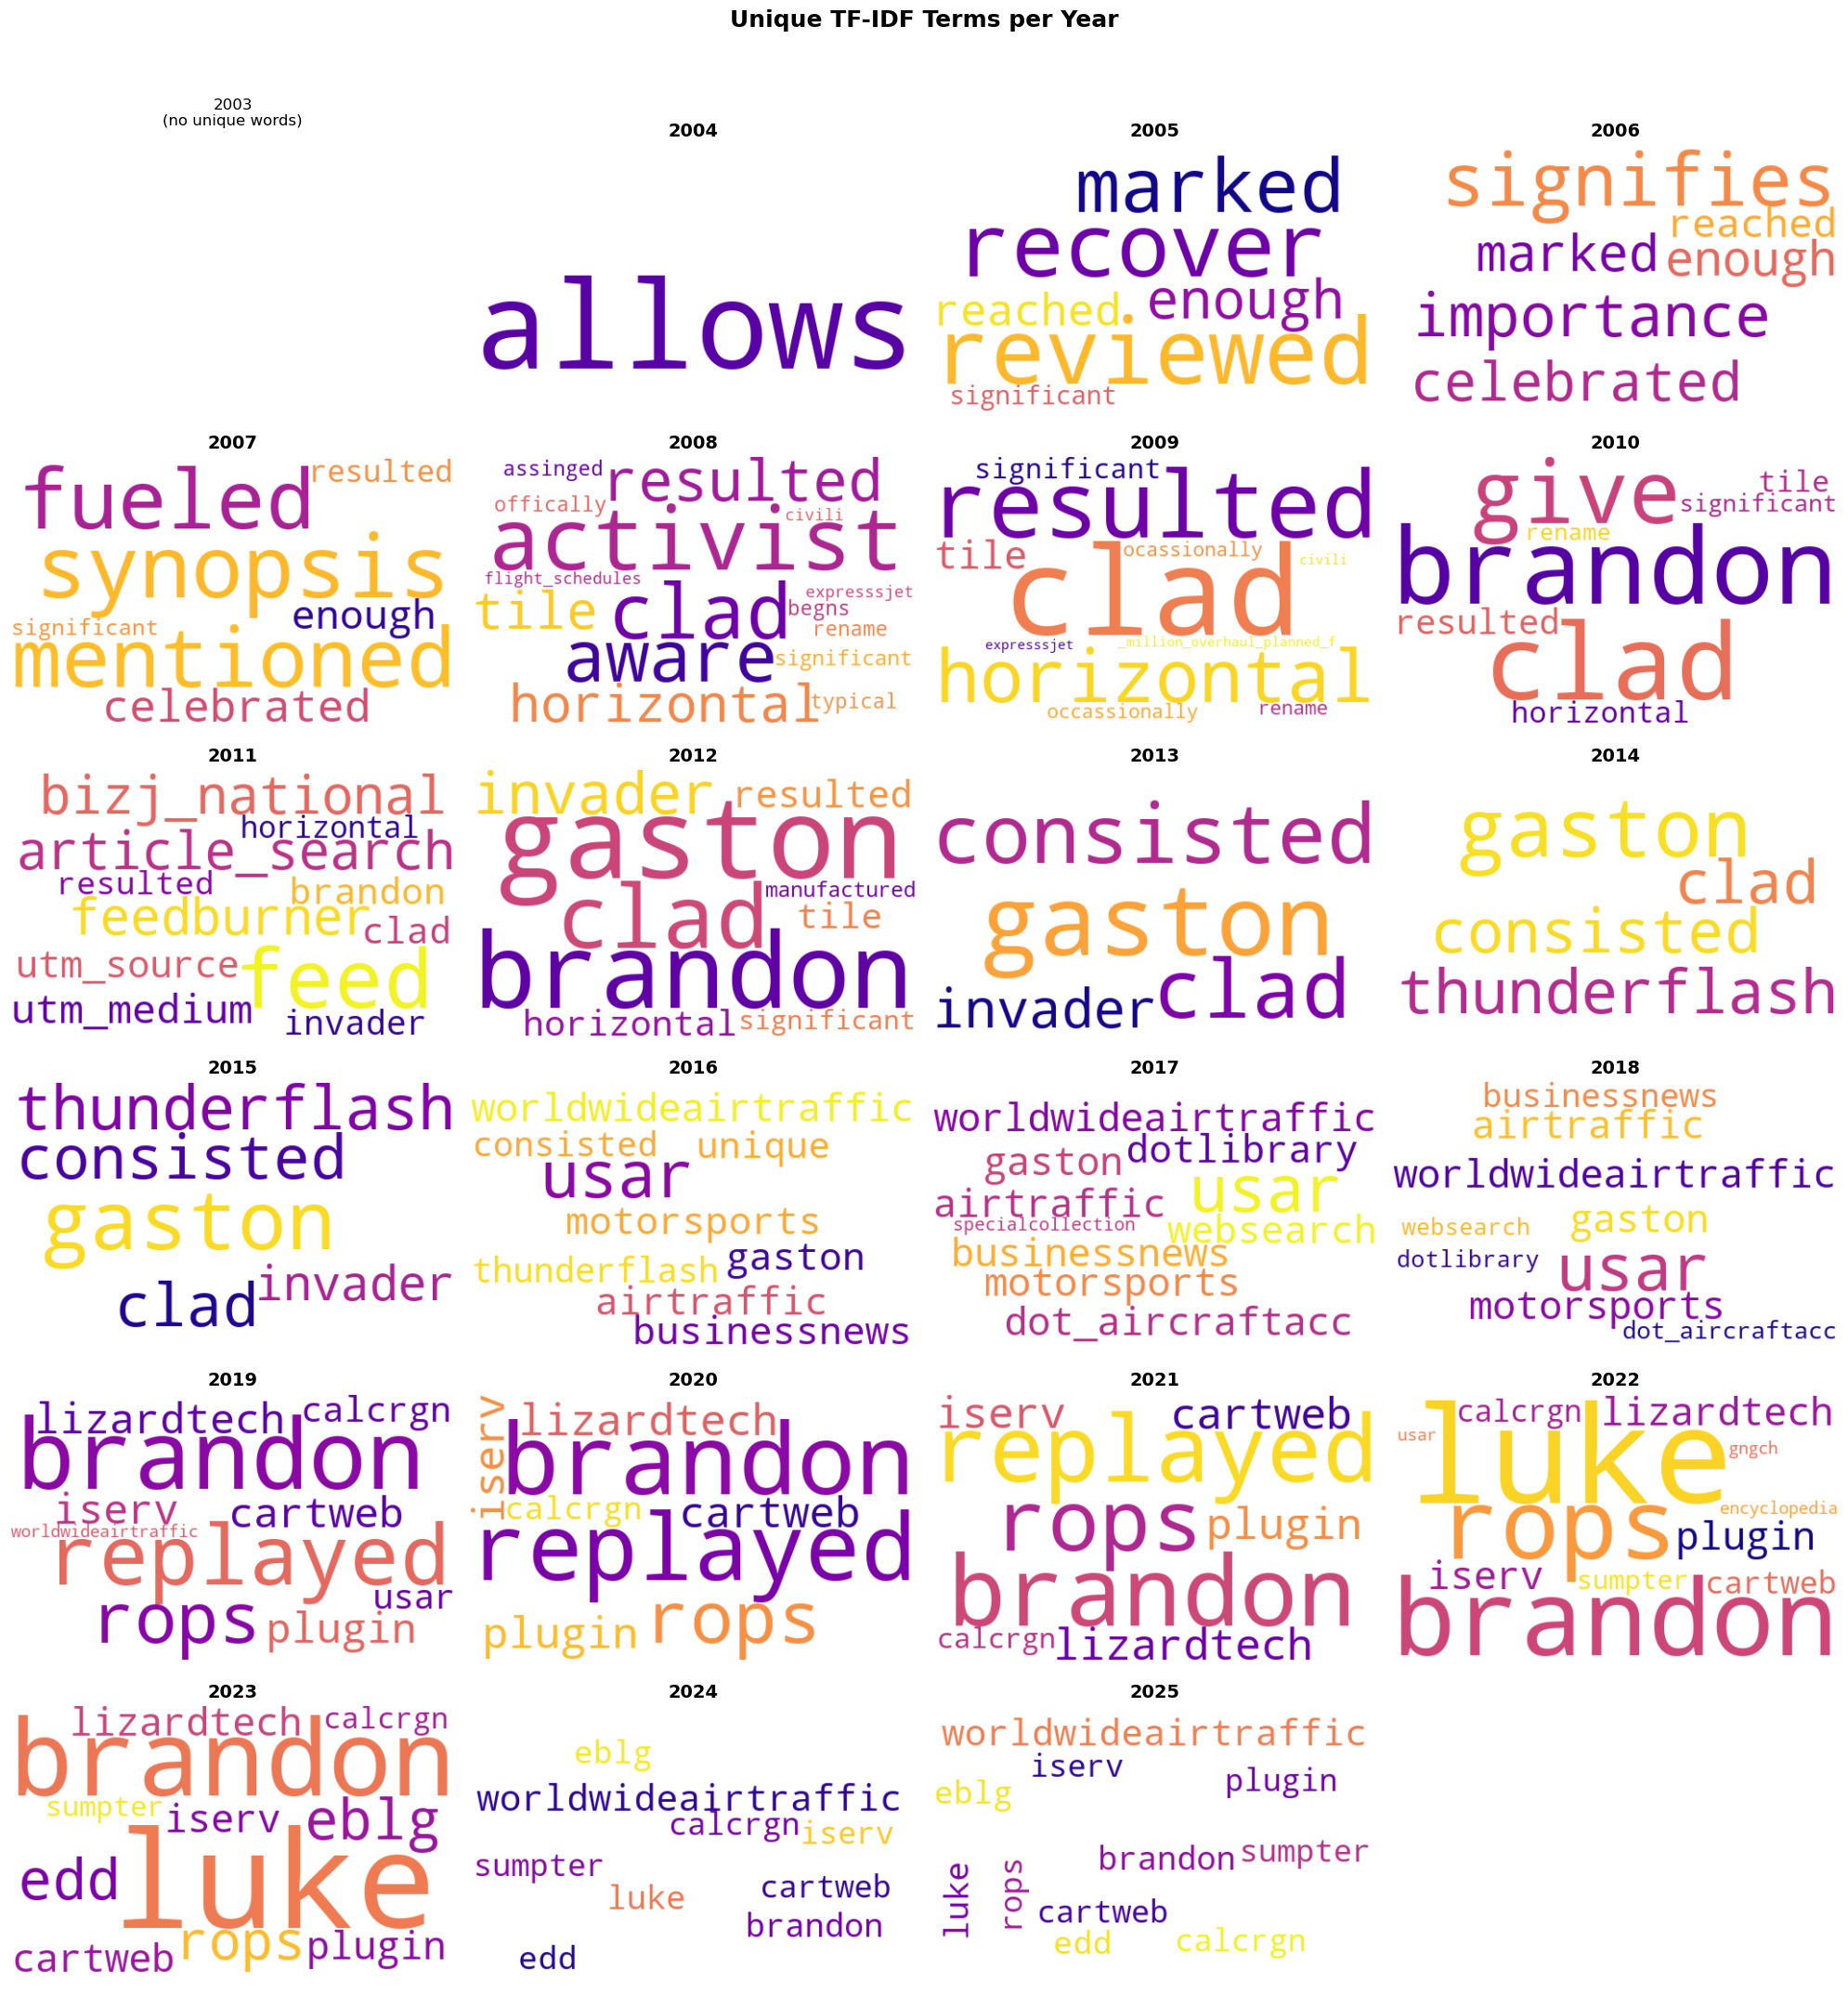

In [28]:
# 4. Keep year order aligned with document order
# -----------------------------
years = df_tokens["Year"].tolist()
documents = df_tokens["token_text"].tolist()


# -----------------------------
# 5. TF-IDF with stop words
# -----------------------------
all_stopwords = list(set(STOPWORDS).union(set(stop_words)))

vectorizer = TfidfVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1, 1)   # only unigrams
)

tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()


# -----------------------------
# 6. Function to get exclusive top words
# -----------------------------
def get_exclusive_top_words(year_to_plot, top_n=100, exclusive_top_n=30):
    if year_to_plot not in years:
        return {}

    y_idx = years.index(year_to_plot)
    all_scores = tfidf_matrix.toarray()
    year_scores = all_scores[y_idx]

    # Top words in this year
    top_indices_this_year = set(np.argsort(year_scores)[-top_n:])

    # Words that are also top words in other years
    common_indices = set()
    for i, yr in enumerate(years):
        if yr == year_to_plot:
            continue
        top_other = set(np.argsort(all_scores[i])[-exclusive_top_n:])
        common_indices |= top_other

    # Keep only unique words for this year
    unique_indices = top_indices_this_year - common_indices

    word_scores = {
        feature_names[i]: year_scores[i]
        for i in unique_indices
        if year_scores[i] > 0
    }

    return word_scores


# -----------------------------
# 7. Plot word cloud grid
# -----------------------------
def show_wordcloud_grid(year_range=range(2003, 2026), top_n=100, exclusive_top_n=30, cols=4):
    years_to_plot = [year for year in year_range if year in years]
    rows = -(-len(years_to_plot) // cols)  # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5))
    axes = np.array(axes).flatten()

    for ax, year in zip(axes, years_to_plot):
        word_scores = get_exclusive_top_words(
            year,
            top_n=top_n,
            exclusive_top_n=exclusive_top_n
        )

        if not word_scores:
            ax.set_title(f"{year}\n(no unique words)", fontsize=12)
            ax.axis("off")
            continue

        wc = WordCloud(
            width=500,
            height=300,
            background_color="white",
            colormap="plasma",
            max_words=40
        ).generate_from_frequencies(word_scores)

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(str(year), fontsize=14, fontweight="bold")
        ax.axis("off")

    # Turn off unused axes
    for ax in axes[len(years_to_plot):]:
        ax.axis("off")

    plt.suptitle("Unique TF-IDF Terms per Year", fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("wordcloud_grid.png", dpi=150, bbox_inches="tight")
    plt.show()


# -----------------------------
# 8. Run it
# -----------------------------
show_wordcloud_grid(year_range=range(2003, 2026), cols=4)

<span style="color:red">In the TF-IDF WordCloud visualizaztion above it can be observed that some of the yeares there few to none words, the reason for this is because the visualization only shows the words there is inuque for that exact your, the reason we wanted to see the development of the used words over time. If we didn't do this it would have let to many generaic words would appear in all of the years. But this is not the only reason that there is none unique TF-IDF words in 2003, because in 2003 we were only abel to gather 186 words which is a rally small portion when contrasting to the other years where there are gatheres up to 5000 words and because of the few words it is more likely that the words used in 2003 apreas as commen words in the other years. </span>

# Creating the two periods we want to compare:

In [31]:
# Loading the lemmatized tokens csv file
df_tokens = pd.read_csv("airport_tokens_lemmatized.csv")

# Convert the saved string representation of lists back into real Python lists
df_tokens["token_text"] = df_tokens["token_text"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else x
)

# If some rows are still plain strings, split them into token lists
df_tokens["token_text"] = df_tokens["token_text"].apply(
    lambda x: x.split() if isinstance(x, str) else x
)

# Convert token lists to strings for TfidfVectorizer
df_tokens["token_text"] = df_tokens["token_text"].apply(
    lambda tokens: " ".join(tokens)
)

# Check that tokens are now real lists
print(type(df_tokens["token_text"].iloc[0]))
print(df_tokens["token_text"].iloc[0][:20])

# Split into periods
df_tokens_valid = df_tokens.dropna(subset=["token_text"])

period_a = df_tokens_valid[
    (df_tokens_valid["Year"] >= 2003) &
    (df_tokens_valid["Year"] <= 2014)
]

period_b = df_tokens_valid[
    (df_tokens_valid["Year"] >= 2015) &
    (df_tokens_valid["Year"] <= 2025)
]

# Flatten token lists
tokens_a = [token for token_list in period_a["token_text"] for token in token_list]
tokens_b = [token for token_list in period_b["token_text"] for token in token_list]

print(tokens_a[:30])
print(tokens_b[:30])

print(len(period_a), "records in period A")
print(len(period_b), "records in period B")
print(len(tokens_a), "tokens in period A")
print(len(tokens_b), "tokens in period B")

<class 'str'>
birmingham internati
['b', 'i', 'r', 'm', 'i', 'n', 'g', 'h', 'a', 'm', ' ', 'i', 'n', 't', 'e', 'r', 'n', 'a', 't', 'i', 'o', 'n', 'a', 'l', ' ', 'a', 'i', 'r', 'p', 'o']
['b', 'i', 'r', 'm', 'i', 'n', 'g', 'h', 'a', 'm', ' ', 'e', 'n', 'g', 'l', 'a', 'n', 'd', ' ', 'a', 'i', 'r', 'p', 'o', 'r', 't', ' ', 'b', 'i', 'r']
4644 records in period A
4257 records in period B
24290728 tokens in period A
61446290 tokens in period B


# TF-IDF WordCloud for the time period 2003-2014

In [38]:
vectorizer_a = TfidfVectorizer(stop_words=list(set(STOPWORDS).union(set(stop_words))), ngram_range=(1,1))

tfidf_matrix_a = vectorizer_a.fit_transform(tokens_a)
feature_names_a = vectorizer_a.get_feature_names_out()

ValueError: empty vocabulary; perhaps the documents only contain stop words

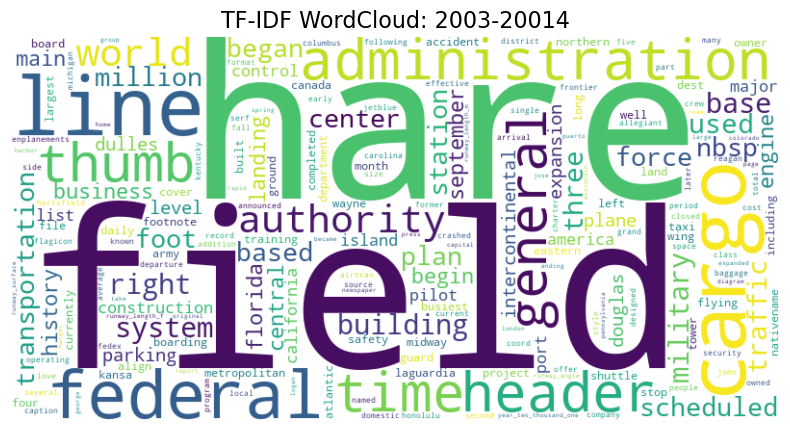

In [ ]:
# Sum TF-IDF scores across all documents (stays sparse until the final small sum)
scores = np.asarray(tfidf_matrix_a.sum(axis=0)).flatten()  # shape: (18307,)

word_scores = dict(zip(feature_names_a, scores))

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
).generate_from_frequencies(word_scores)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("TF-IDF WordCloud: 2003-2014", fontsize=16)
plt.show()

# TF-IDF WordCloud for the time period 2015-2025

In [44]:
vectorizer_a = TfidfVectorizer(stop_words=list(set(STOPWORDS).union(set(stop_words))), ngram_range=(1,1))

tfidf_matrix_b = vectorizer_a.fit_transform(tokens_b)
feature_names_b = vectorizer_a.get_feature_names_out()

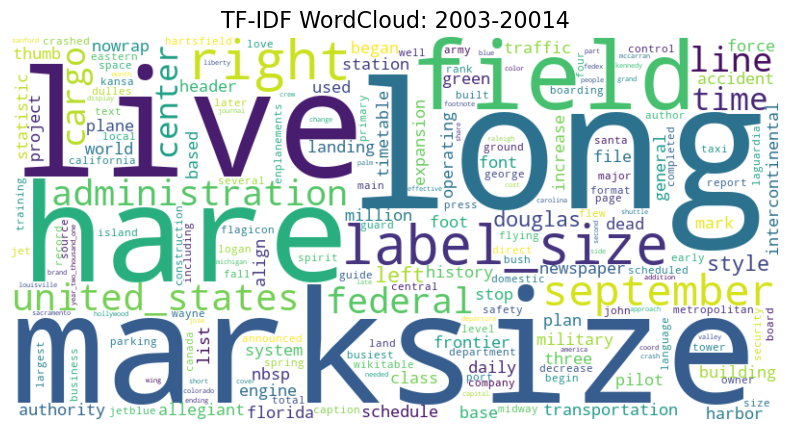

In [ ]:
# Sum TF-IDF scores across all documents (stays sparse until the final small sum)
scores = np.asarray(tfidf_matrix_b.sum(axis=0)).flatten()  # shape: (18307,)

word_scores = dict(zip(feature_names_b, scores))

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
).generate_from_frequencies(word_scores)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("TF-IDF WordCloud: 2003-2014", fontsize=16)
plt.show()

# The difference in TF-IDF scores from the two time periods

c:\Users\malth\miniconda3\envs\dtu02450\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


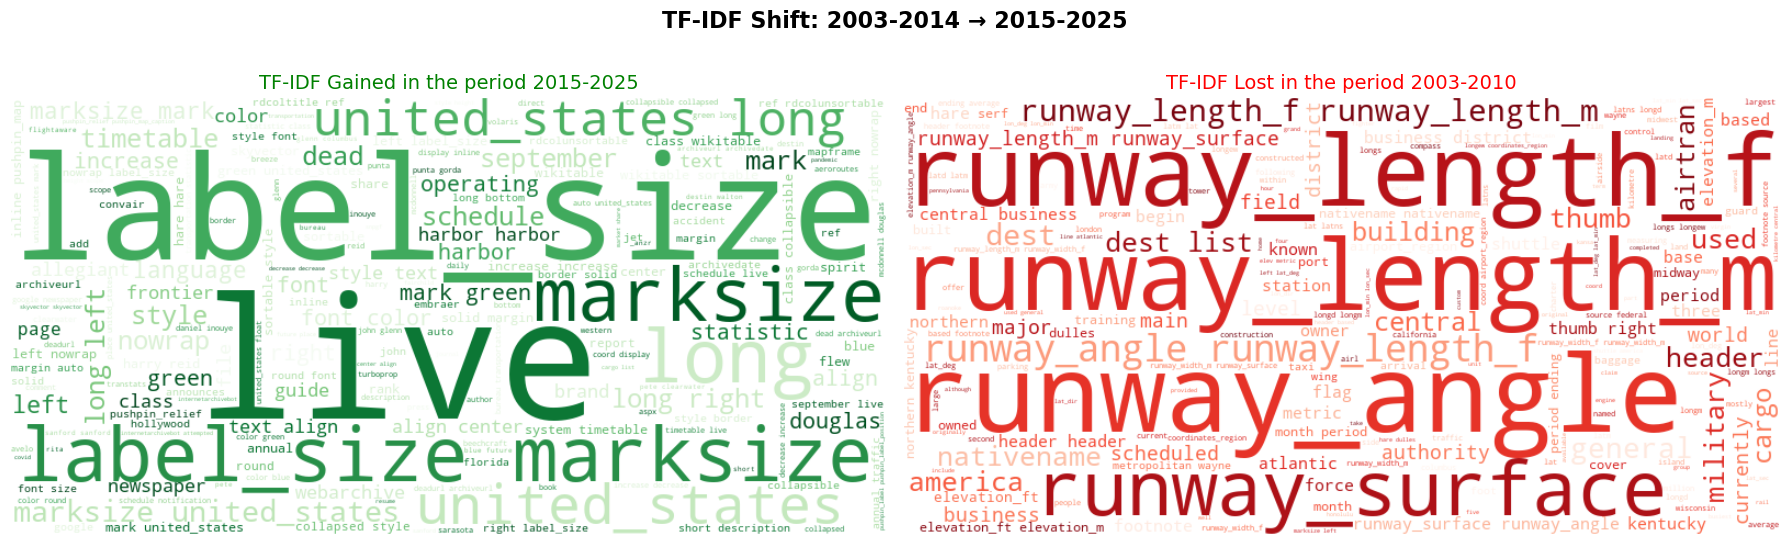

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS
from nltk.stem import WordNetLemmatizer
import numpy as np
import matplotlib.pyplot as plt


# Treat each corpus as a single "document" for comparison
doc_a = " ".join(tokens_a)
doc_b = " ".join(tokens_b)

# Fit ONE vectorizer on BOTH corpora — shared vocabulary
vectorizer = TfidfVectorizer(stop_words=list(set(STOPWORDS).union(set(stop_words))), ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform([doc_a, doc_b])  # shape: (2, vocab_size)

feature_names = vectorizer.get_feature_names_out()
scores_a = np.asarray(tfidf_matrix[0].todense()).flatten()
scores_b = np.asarray(tfidf_matrix[1].todense()).flatten()

# Difference: positive = rose in B, negative = fell in B
diff_scores = scores_b - scores_a

# Words that INCREASED going from A → B
gained = {feature_names[i]: diff_scores[i] for i in range(len(diff_scores)) if diff_scores[i] > 0}

# Words that DECREASED going from A → B
lost   = {feature_names[i]: abs(diff_scores[i]) for i in range(len(diff_scores)) if diff_scores[i] < 0}

# --- Plot side-by-side wordclouds of the DELTA ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_gained = WordCloud(width=800, height=400, background_color='white',
                      colormap='Greens').generate_from_frequencies(gained)
axes[0].imshow(wc_gained, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title("TF-IDF Gained in the period 2015-2025", fontsize=14, color='green')

wc_lost = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds').generate_from_frequencies(lost)
axes[1].imshow(wc_lost, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title("TF-IDF Lost in the period 2003-2010", fontsize=14, color='red')

plt.suptitle("TF-IDF Shift: 2003-2014 → 2015-2025", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
top_gained = sorted(gained.items(), key=lambda x: x[1], reverse=True)[:5]
top_lost   = sorted(lost.items(),   key=lambda x: x[1], reverse=True)[:5]
print("Top gained:", top_gained)
print("Top lost:",   top_lost)

Top gained: [('live', np.float64(0.13445146208338954)), ('label_size', np.float64(0.12934733872446394)), ('label_size marksize', np.float64(0.12912732896630963)), ('marksize', np.float64(0.12833115297105635)), ('long', np.float64(0.12798211491182832))]
Top lost: [('runway_angle', np.float64(0.04506459995581975)), ('runway_length_f', np.float64(0.04506459995581975)), ('runway_length_m', np.float64(0.04506459995581975)), ('runway_surface', np.float64(0.04506459995581975)), ('runway_angle runway_length_f', np.float64(0.045010662672808587))]


# Eras and Group the text

In [1]:
# 1. Define the Eras based on the years in your dataset
def get_era_label(year):
    if 2003 <= year <= 2010:
        return "Era 1: Post-9/11 & Growth (2003-2010)"
    elif 2011 <= year <= 2019:
        return "Era 2: Modernization & Events (2011-2019)"
    elif 2020 <= year <= 2025:
        return "Era 3: Pandemic & Recovery (2020-2025)"
    return "Unknown Era"

# Apply the Era labels to your dataframe
df_tokens['Era'] = df_tokens['Year'].apply(get_era_label)

# 2. Group the text by Era
# This combines all the 'token_text' strings for a given Era into one massive string
era_documents = df_tokens.groupby('Era')['token_text'].apply(lambda x: ' '.join(x.dropna())).reset_index()

# Extract the labels and the corpus for the math
era_names = era_documents['Era'].tolist()
era_corpus = era_documents['token_text'].tolist()

print(f"Successfully grouped data into {len(era_names)} distinct Eras.")

NameError: name 'df_tokens' is not defined